In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

from SCIKIT.LESSON1 import Y_test, predictions, comparison
from python1 import X_train




In [2]:
data={

    "hours studied":[1,2,3,4,5,6,7,8,9,10],
    "marks":[55,66,77,88,44,55,66,90,91,100]


}

df=pd.DataFrame(data)
df


,hours studied,marks
0,1,55
1,2,66
2,3,77
3,4,88
4,5,44
5,6,55
6,7,66
7,8,90
8,9,91
9,10,100


In [18]:
X=df[["hours studied"]]
Y=df["marks"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=55)


model=LinearRegression()


model.fit(X_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
predictions=model.predict(X_test)
print(predictions)


[75.89808917 64.42462845]


In [25]:
comparison = pd.DataFrame({
    "Actual marks": Y_test,
    "Predicted marks": predictions
})
comparison


,Actual marks,Predicted marks
4,44,75.898089
0,55,64.424628


In [35]:
 comparison["mse"]=mean_squared_error(Y_test,predictions)
comparison["mae"]=mean_absolute_error(Y_test,predictions)
comparison["r2"]=r2_score(Y_test,predictions)
comparison["rmse"]=mean_squared_error(Y_test,predictions)
comparison["residual"]=comparison["Actual marks"]-comparison["Predicted marks"]
comparison

,Actual marks,Predicted marks,mse,mae,r2,rmse,residual
4,44,75.898089,553.155857,20.661359,-17.286144,553.155857,-31.898089
0,55,64.424628,553.155857,20.661359,-17.286144,553.155857,-9.424628


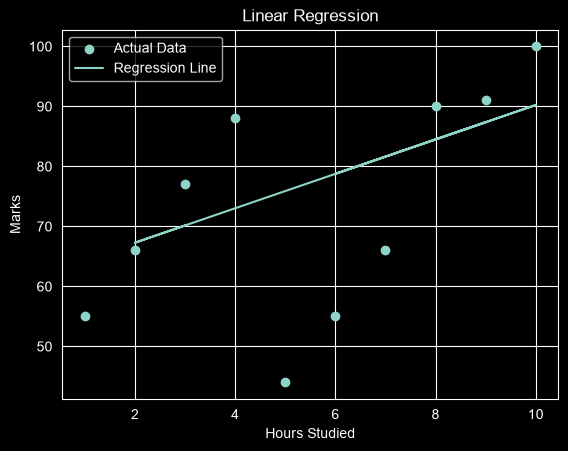

In [50]:
import matplotlib.pyplot as plt

# Actual data
plt.scatter(
    df["hours studied"],
    df["marks"],
    label="Actual Data"
)

# Regression line
plt.plot(
    X_train["hours studied"],
    model.predict(X_train),
    label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Linear Regression")

plt.legend()
plt.grid(True)

plt.show()

In [52]:
train_predictions=model.predict(X_train)
print(train_predictions)


[70.16135881 67.29299363 73.02972399 81.63481953 90.23991507 78.76645435
 87.37154989 84.50318471]


In [55]:
test_predictions=model.predict(X_test)
print(test_predictions)
print(Y_test)

[75.89808917 64.42462845]
4    44
0    55
Name: marks, dtype: int64


In [56]:
from sklearn.metrics import r2_score

train_r2 = r2_score(
    Y_train,
    train_predictions
)

test_r2 = r2_score(
    Y_test,
    test_predictions
)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.28412356908945235
Testing R²: -17.28614403712047


🟦 Lesson: Regularization

We just learned overfitting vs underfitting. The next concept is regularization, which is one of the main techniques used to reduce overfitting.

In [4]:
import pandas as pd

data = {
    "hours studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "marks": [35, 45, 47, 55, 57, 60, 68, 75, 82, 88]
}

df = pd.DataFrame(data)

df

,hours studied,marks
0,1,35
1,2,45
2,3,47
3,4,55
4,5,57
5,6,60
6,7,68
7,8,75
8,9,82
9,10,88


In [5]:
X = df[["hours studied"]]
Y = df["marks"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [7]:
print("X_train:")
print(X_train)

print("\nY_train:")
print(Y_train)

print("\nX_test:")
print(X_test)

print("\nY_test:")
print(Y_test)

X_train:
   hours studied
5              6
0              1
7              8
2              3
9             10
4              5
3              4
6              7

Y_train:
5    60
0    35
7    75
2    47
9    88
4    57
3    55
6    68
Name: marks, dtype: int64

X_test:
   hours studied
8              9
1              2

Y_test:
8    82
1    45
Name: marks, dtype: int64


In [9]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, Y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [11]:
ridge_predictions=ridge_model.predict(X_test)
print("Ridge prediction")
print(ridge_predictions)

Ridge prediction
[80.17161017 41.07838983]


In [12]:
from sklearn.metrics import r2_score
ridge_r2=r2_score(
    Y_test,
    ridge_predictions
)

print("Ridge R2 score")
print(ridge_r2)

Ridge R2 score
0.9726485965028983


In [13]:
print("Ridge coefficient:", ridge_model.coef_)
print("Ridge intercept:", ridge_model.intercept_)

Ridge coefficient: [5.58474576]
Ridge intercept: 29.908898305084747


In [27]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=10)


In [28]:
lasso_model.fit(X_train,Y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [29]:
lasso_predictions=lasso_model.predict(X_test)

print("lasso prediction")
print(lasso_predictions)
comparison=pd.DataFrame({
    "Actual marks": Y_test,
    "Predicted marks": lasso_predictions
})
comparison

lasso prediction
[75.68103448 45.56896552]


,Actual marks,Predicted marks
8,82,75.681034
1,45,45.568966


In [30]:
print("lasso-coefficent",lasso_model.coef_)
print("lasso intercept",lasso_model.intercept_)

lasso-coefficent [4.30172414]
lasso intercept 36.96551724137931


In [31]:
from sklearn.metrics import r2_score
lasso_r2=r2_score(

    Y_test,
    lasso_predictions

)
print("lasso R2 score")
print(lasso_r2)

lasso R2 score
0.9411935033339731


In [32]:
 from sklearn.metrics import mean_absolute_error

lasso_mae = mean_absolute_error(
    Y_test,
    lasso_predictions
)

print("Lasso MAE:", lasso_mae)

Lasso MAE: 3.443965517241381


****__Great. Let's do the practical Ridge vs Lasso comparison.

🟦 Lesson: Ridge vs Lasso

We already have:__****

In [33]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, Y_train)

ridge_predictions = ridge_model.predict(X_test)

In [34]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, Y_train)

lasso_predictions = lasso_model.predict(X_test)

In [35]:
print("Ridge coefficient:", ridge_model.coef_)
print("Lasso coefficient:", lasso_model.coef_)

Ridge coefficient: [5.58474576]
Lasso coefficient: [5.66724138]


In [36]:
print("Ridge Predictions:")
print(ridge_predictions)

print("\nLasso Predictions:")
print(lasso_predictions)

Ridge Predictions:
[80.17161017 41.07838983]

Lasso Predictions:
[80.46034483 40.78965517]


In [37]:
from sklearn.metrics import r2_score

ridge_r2 = r2_score(Y_test, ridge_predictions)
lasso_r2 = r2_score(Y_test, lasso_predictions)

print("Ridge R²:", ridge_r2)
print("Lasso R²:", lasso_r2)

Ridge R²: 0.9726485965028983
Lasso R²: 0.9706390918668774


In [38]:
from sklearn.metrics import mean_absolute_error

ridge_mae = mean_absolute_error(Y_test, ridge_predictions)
lasso_mae = mean_absolute_error(Y_test, lasso_predictions)

print("Ridge MAE:", ridge_mae)
print("Lasso MAE:", lasso_mae)

Ridge MAE: 2.8750000000000036
Lasso MAE: 2.8749999999999964


In [40]:
print("========== RIDGE ==========")
print("Coefficient:", ridge_model.coef_)
print("R²:", ridge_r2)
print("MAE:", ridge_mae)

print("\n========== LASSO ==========")
print("Coefficient:", lasso_model.coef_)
print("R²:", lasso_r2)
print("MAE:", lasso_mae)

========== RIDGE ==========
Coefficient: [5.58474576]
R²: 0.9726485965028983
MAE: 2.8750000000000036

========== LASSO ==========
Coefficient: [5.66724138]
R²: 0.9706390918668774
MAE: 2.8749999999999964


# MULTIPLE LINEAR REGRESSION

In [41]:
import pandas as pd

data = {
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "sleep_hours": [5, 6, 6, 7, 7, 8, 8, 8, 9, 9],
    "attendance": [60, 65, 70, 72, 75, 80, 82, 85, 90, 95],
    "marks": [35, 42, 48, 55, 58, 65, 70, 76, 83, 90]
}

df = pd.DataFrame(data)

df

,hours_studied,sleep_hours,attendance,marks
0,1,5,60,35
1,2,6,65,42
2,3,6,70,48
3,4,7,72,55
4,5,7,75,58
5,6,8,80,65
6,7,8,82,70
7,8,8,85,76
8,9,9,90,83
9,10,9,95,90


In [42]:
X=df[
    [
        "hours_studied",
        "sleep_hours",
        "attendance",


    ]
]
Y=df[["marks"]]

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(

    X,
    Y,
    test_size=0.2,
    random_state=42

)

NameError: name 'X' is not defined

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [49]:
model.fit(X_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[3.45293315 0.38335607 0.62892224]]
Intercept: [-8.30832196]


In [52]:
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

hours_studied : [3.45293315 0.38335607 0.62892224]


In [53]:
print("Intercept:", model.intercept_)

Intercept: [-8.30832196]


In [54]:
predictions = model.predict(X_test)

print(predictions)

[[82.8212824 ]
 [41.77762619]]


In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(
    Y_test,
    predictions
)

print("R²:", r2)

R²: 0.9999031646759344


In [56]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    Y_test,
    predictions
)

print("MAE:", mae)

MAE: 0.20054570259209115


In [57]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    Y_test,
    predictions
)

print("MAE:", mae)

MAE: 0.20054570259209115


In [58]:
print("Coefficients:", model.coef_)

Coefficients: [[3.45293315 0.38335607 0.62892224]]


# Lesson: Evaluating Multiple Linear Regression

Now that you've learned how to build the model and make predictions, we need to answer:

How good is our Multiple Linear Regression model?

We'll use the same evaluation concepts you learned with simple Linear Regression.

In [59]:
train_predictions=model.predict(X_train)

In [60]:
test_predictions=model.predict(X_test)

In [61]:
from sklearn.metrics import r2_score
train_r2=r2_score(
    Y_train,
    train_predictions
)
print("Trainng R2 score")
print(train_r2)


Trainng R2 score
0.9978376246794607


In [62]:
test_r2 = r2_score(
    Y_test,
    test_predictions
)

print("Testing R²:", test_r2)

Testing R²: 0.9999031646759344


In [63]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    Y_test,
    test_predictions
)

print("MAE:", mae)

MAE: 0.20054570259209115


In [64]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    Y_test,
    test_predictions
)

print("MSE:", mse)

MSE: 0.04069504493857248


In [65]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.2017301289807065


In [66]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_r2 = r2_score(Y_train, train_predictions)
test_r2 = r2_score(Y_test, test_predictions)

mae = mean_absolute_error(Y_test, test_predictions)

mse = mean_squared_error(Y_test, test_predictions)

rmse = np.sqrt(mse)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)
print("MAE        :", mae)
print("MSE        :", mse)
print("RMSE       :", rmse)

Training R²: 0.9978376246794607
Testing R² : 0.9999031646759344
MAE        : 0.20054570259209115
MSE        : 0.04069504493857248
RMSE       : 0.2017301289807065


In [2]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [3]:
scaler.fit(X_train)

NameError: name 'X_train' is not defined